In [1]:
import pandas as pd
import numpy as np

# LOAD DATASET

In [2]:
df = pd.read_csv('Taxi_Trip_Price.csv')
df.head(100)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
95,NaN,Morning,Weekend,1.0,Medium,Clear,3.43,0.91,0.50,67.43,60.0770
96,26.61,Morning,Weekday,4.0,Low,Rain,3.07,0.68,0.18,65.91,33.0286
97,21.95,Morning,Weekday,3.0,Medium,Clear,4.05,0.88,0.10,44.99,27.8650
98,2.25,Evening,Weekend,3.0,Low,Clear,3.99,1.88,0.50,NaN,40.6500


## Deskripsi Variabel – Dataset Taxi Trip

| Variabel | Tipe Data | Meaning |
|---|---|---|
| **Trip_Distance_km** | Float | Jarak perjalanan yang ditempuh dalam satu trip yang diukur dalam kilometer. |
| **Time_of_Day** | Kategorikal | Waktu terjadinya perjalanan, misalnya pagi, siang, sore, atau malam. |
| **Day_of_Week** | Kategorikal | Hari dalam seminggu ketika perjalanan terjadi (Senin hingga Minggu). |
| **Passenger_Count** | Integer | Jumlah penumpang yang ikut dalam satu perjalanan. |
| **Traffic_Conditions** | Kategorikal | Kondisi lalu lintas selama perjalanan, seperti lancar, sedang, atau padat. |
| **Weather** | Kategorikal | Kondisi cuaca saat perjalanan berlangsung, seperti cerah, hujan, atau berkabut. |
| **Base_Fare** | Float | Tarif dasar yang dikenakan pada awal perjalanan sebelum memperhitungkan jarak dan durasi perjalanan. |
| **Per_Km_Rate** | Float | Tarif tambahan yang dikenakan untuk setiap kilometer perjalanan. |
| **Per_Minute_Rate** | Float | Tarif tambahan yang dikenakan berdasarkan durasi perjalanan per menit. |
| **Trip_Duration_Minutes** | Integer | Total durasi perjalanan dari awal hingga selesai dalam satuan menit. |
| **Trip_Price** | Float | Total biaya perjalanan yang dibayarkan pelanggan setelah seluruh komponen tarif dihitung. |

# SUMMARY INFORMATION

In [3]:
# ringkasan dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [4]:
# ringkasan statistik deskriptif
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [5]:
# cek missing value
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [6]:
# cek missing percentage
missing_percentage = df.isnull().sum() * 100 / len(df)
missing_percentage

# ringkasan keputusan untuk missing value
def missing_decision(pct):
    if pct < 5:
        return "Aman dihapus"
    elif 5 <= pct < 20:
        return "Pertimbangkan konteks"
    elif 20 <= pct <= 40:
        return "Lebih baik imputasi"
    else:
        return "Pertimbangkan hapus kolom"

missing_summary = pd.DataFrame({'Persentase Missing (%)': missing_percentage})
missing_summary['Keputusan'] = missing_summary['Persentase Missing (%)'].apply(missing_decision)
missing_summary = missing_summary.sort_values(by='Persentase Missing (%)',ascending=False)
missing_summary

,Persentase Missing (%),Keputusan
Trip_Distance_km,5.0,Pertimbangkan konteks
Time_of_Day,5.0,Pertimbangkan konteks
Day_of_Week,5.0,Pertimbangkan konteks
Passenger_Count,5.0,Pertimbangkan konteks
Traffic_Conditions,5.0,Pertimbangkan konteks
Weather,5.0,Pertimbangkan konteks
Base_Fare,5.0,Pertimbangkan konteks
Per_Km_Rate,5.0,Pertimbangkan konteks
Per_Minute_Rate,5.0,Pertimbangkan konteks
Trip_Duration_Minutes,5.0,Pertimbangkan konteks


In [7]:
# cek nilai duplikat
df.duplicated().sum()

np.int64(0)

In [8]:
# cek nilai unik
pd.set_option('display.max_colwidth', None)
unique_summary = pd.DataFrame({
    'n_unique': df.nunique(),
    'unique_values': df.apply(lambda x: x.unique())
})

unique_summary

,n_unique,unique_values
Trip_Distance_km,867,"[19.35, 47.59, 36.87, 30.33, nan, 8.64, 3.85, 43.44, 30.45, 35.7, 48.53, 41.79, 11.4, 9.91, 9.99, 15.91, 26.71, 22.17, 15.27, 30.98, 7.84, 105.94355003672597, 18.95, 23.35, 39.47, 10.78, 138.09832791310237, 30.03, 3.28, 30.77, 9.36, 4.19, 47.5, 48.32, 40.61, 15.93, 5.79, 34.53, 22.57, 6.98, 25.26, 2.69, 45.56, 13.68, 33.46, 16.27, 26.48, 27.79, 10.06, 48.51, 38.98, 47.04, 44.85, 30.3, 46.17, 5.34, 10.6, 3.22, 16.94, 20.05, 14.3, 41.61, 18.48, 146.0670471598387, 27.59, 7.91, 40.31, 4.65, 49.36, 38.84, 10.74, 1.27, 40.96, 35.64, 36.72, 38.79, 4.63, 18.56, 6.68, 43.29, 31.54, 17.21, 4.11, 16.93, 36.75, 44.47, 24.14, 6.86, 35.95, 38.28, 28.5, 38.78, 26.61, 21.95, 2.25, 6.29, 2.54, 32.18, 16.4, 25.92, ...]"
Time_of_Day,4,"[Morning, Afternoon, Evening, Night, nan]"
Day_of_Week,2,"[Weekday, Weekend, nan]"
Passenger_Count,4,"[3.0, 1.0, 4.0, 2.0, nan]"
Traffic_Conditions,3,"[Low, High, Medium, nan]"
Weather,3,"[Clear, nan, Rain, Snow]"
Base_Fare,290,"[3.56, nan, 2.7, 3.48, 2.93, 2.55, 3.51, 2.97, 2.77, 3.39, 2.4, 4.78, 4.6, 4.12, 2.32, 4.33, 4.42, 4.3, 2.34, 3.93, 4.5, 3.73, 3.94, 3.38, 3.59, 3.92, 2.24, 3.31, 2.88, 3.64, 4.07, 4.39, 2.49, 2.31, 2.44, 4.63, 3.58, 3.4, 3.95, 3.88, 2.23, 2.15, 2.41, 3.16, 4.83, 3.83, 4.13, 4.21, 2.83, 3.02, 4.99, 2.79, 2.84, 4.79, 2.07, 4.09, 4.18, 4.51, 4.92, 4.93, 2.2, 4.47, 2.39, 4.95, 4.74, 3.32, 2.12, 3.09, 4.48, 4.1, 2.17, 3.28, 3.41, 3.08, 3.43, 3.07, 4.05, 3.99, 4.15, 2.8, 2.95, 2.38, 3.97, 3.79, 4.61, 3.35, 4.01, 4.46, 2.73, 3.26, 4.52, 3.65, 2.58, 4.73, 4.28, 4.53, 3.03, 2.27, 4.27, 3.75, ...]"
Per_Km_Rate,150,"[0.8, 0.62, 1.21, 0.51, 0.63, 1.71, 1.66, 1.87, 1.78, 1.52, 0.58, nan, 1.77, 1.26, 0.85, 1.59, 1.97, 0.73, 0.84, 0.82, 1.69, 0.78, 0.6, 0.54, 1.75, 1.05, 1.76, 1.33, 1.85, 1.89, 0.61, 0.88, 1.5, 1.83, 1.41, 1.95, 0.9, 1.25, 0.72, 1.16, 1.0, 1.28, 1.38, 1.64, 1.57, 1.63, 1.93, 0.86, 0.99, 1.37, 1.03, 1.55, 1.34, 1.08, 1.13, 1.82, 1.56, 1.88, 0.91, 1.35, 1.91, 1.61, 1.12, 0.57, 0.79, 1.18, 0.95, 1.62, 0.68, 1.3, 1.39, 0.69, 1.31, 1.9, 0.96, 1.8, 1.65, 0.87, 0.55, 0.65, 1.06, 0.67, 1.11, 1.23, 1.73, 0.76, 1.54, 0.71, 1.29, 1.46, 1.01, 1.86, 1.17, 1.24, 1.84, 1.53, 1.79, 0.98, 0.77, 0.7, ...]"
Per_Minute_Rate,41,"[0.32, 0.43, 0.15, 0.48, nan, 0.23, 0.34, 0.47, 0.5, 0.11, 0.21, 0.2, 0.41, 0.12, 0.25, 0.3, 0.39, 0.24, 0.35, 0.33, 0.36, 0.13, 0.19, 0.44, 0.38, 0.42, 0.26, 0.18, 0.17, 0.29, 0.28, 0.31, 0.37, 0.46, 0.16, 0.4, 0.1, 0.27, 0.49, 0.45, 0.14, 0.22]"
Trip_Duration_Minutes,917,"[53.82, 40.57, 37.27, 116.81, 22.64, 89.33, 5.05, nan, 110.33, 26.34, 79.94, 86.95, 84.12, 41.72, 34.0, 114.93, 111.18, 57.59, 57.02, 53.8, 23.03, 54.04, 66.8, 7.59, 56.07, 94.86, 83.21, 78.04, 109.6, 7.07, 69.06, 95.55, 67.25, 42.25, 20.67, 107.07, 59.14, 105.98, 72.37, 82.53, 97.49, 80.8, 50.78, 64.07, 97.35, 47.97, 49.63, 16.0, 110.18, 15.47, 79.54, 52.52, 51.65, 83.15, 12.72, 73.28, 93.78, 100.24, 24.61, 108.2, 106.41, 60.81, 67.33, 110.69, 108.49, 56.54, 36.56, 50.21, 49.59, 37.99, 35.89, 104.02, 13.03, 82.93, 24.87, 44.62, 12.08, 36.05, 93.37, 106.78, 30.48, 58.31, 59.09, 105.46, 92.72, 64.0, 82.14, 102.45, 6.1, 51.33, 109.33, 90.14, 67.43, 65.91, 44.99, 80.37, 53.11, 87.13, 104.04, 22.79, ...]"


In [9]:
# cek outliers
numeric_cols = [
    'Trip_Distance_km',
    'Passenger_Count',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes',
    'Trip_Price'
]

def detect_outliers_iqr(df, columns):
    outlier_summary = {}

    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = {
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_count': outliers.shape[0]
        }

    return pd.DataFrame(outlier_summary).T

outlier_summary = detect_outliers_iqr(df, numeric_cols)
outlier_summary

,lower_bound,upper_bound,outlier_count
Trip_Distance_km,-26.02625,77.06375,20.0
Passenger_Count,-1.37500,5.62500,0.0
Base_Fare,0.43500,6.55500,0.0
Per_Km_Rate,-0.26500,2.73500,0.0
Per_Minute_Rate,-0.11000,0.69000,0.0
Trip_Duration_Minutes,-43.87625,168.81375,0.0
Trip_Price,-19.29240,122.13440,26.0


In [10]:
# Outlier 1 - Trip_Distance_km
Q1 = df['Trip_Distance_km'].quantile(0.25)
Q3 = df['Trip_Distance_km'].quantile(0.75)
IQR = Q3 - Q1

lower_Trip_Distance_km = Q1 - 1.5 * IQR
upper_Trip_Distance_km = Q3 + 1.5 * IQR

Trip_Distance_km_outliers = df[(df['Trip_Distance_km'] < lower_Trip_Distance_km) | (df['Trip_Distance_km'] > upper_Trip_Distance_km)]

Trip_Distance_km_outliers

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
22,105.943550,Night,Weekend,2.0,Low,Rain,3.94,1.69,0.32,23.03,201.869509
27,138.098328,Evening,Weekend,4.0,Medium,Rain,2.24,1.75,0.32,94.86,280.877302
64,146.067047,Afternoon,Weekday,2.0,Medium,Clear,4.79,0.73,0.30,60.81,320.958664
108,112.830958,Afternoon,Weekday,2.0,High,Snow,3.35,1.90,0.23,78.63,233.008285
110,102.747556,Evening,Weekday,2.0,Medium,Clear,2.23,1.80,0.23,53.09,274.535087
141,109.616082,Afternoon,Weekday,4.0,High,Clear,4.46,1.69,0.23,53.88,327.217665
225,130.809001,Afternoon,Weekday,1.0,High,Clear,3.93,0.63,0.16,88.31,328.871769
267,116.196064,Afternoon,Weekend,4.0,Medium,Clear,2.20,0.85,0.25,19.63,206.699570
268,139.062230,Afternoon,Weekday,2.0,Low,Rain,2.80,1.82,0.14,50.83,276.840597
287,100.380420,Afternoon,Weekday,3.0,Medium,Rain,4.46,NaN,NaN,89.21,329.913004


In [11]:
# Outlier 2 - Trip_Price
Q1 = df['Trip_Price'].quantile(0.25)
Q3 = df['Trip_Price'].quantile(0.75)
IQR = Q3 - Q1

lower_Trip_Price = Q1 - 1.5 * IQR
upper_Trip_Price = Q3 + 1.5 * IQR

Trip_Price_outliers = df[(df['Trip_Price'] < lower_Trip_Price) | (df['Trip_Price'] > upper_Trip_Price)]

Trip_Price_outliers

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
22,105.943550,Night,Weekend,2.0,Low,Rain,3.94,1.69,0.32,23.03,201.869509
27,138.098328,Evening,Weekend,4.0,Medium,Rain,2.24,1.75,0.32,94.86,280.877302
64,146.067047,Afternoon,Weekday,2.0,Medium,Clear,4.79,0.73,0.30,60.81,320.958664
108,112.830958,Afternoon,Weekday,2.0,High,Snow,3.35,1.90,0.23,78.63,233.008285
110,102.747556,Evening,Weekday,2.0,Medium,Clear,2.23,1.80,0.23,53.09,274.535087
141,109.616082,Afternoon,Weekday,4.0,High,Clear,4.46,1.69,0.23,53.88,327.217665
225,130.809001,Afternoon,Weekday,1.0,High,Clear,3.93,0.63,0.16,88.31,328.871769
267,116.196064,Afternoon,Weekend,4.0,Medium,Clear,2.20,0.85,0.25,19.63,206.699570
268,139.062230,Afternoon,Weekday,2.0,Low,Rain,2.80,1.82,0.14,50.83,276.840597
287,100.380420,Afternoon,Weekday,3.0,Medium,Rain,4.46,NaN,NaN,89.21,329.913004


# DISTRIBUTION AUDIT

In [12]:
# Deskriptive Statistik mendalam
num_cols = [
    'Trip_Distance_km',
    'Passenger_Count',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes',
    'Trip_Price'
]

df[num_cols].describe().T
df[num_cols].skew()

Trip_Distance_km         2.236010
Passenger_Count          0.016255
Base_Fare               -0.005149
Per_Km_Rate              0.079206
Per_Minute_Rate          0.058695
Trip_Duration_Minutes    0.017749
Trip_Price               3.732561
dtype: float64

- Skewed > 1 --> **Highly Skewed** --> Median atau pertimbangkan log transform
  
- 0.5 <= Skewed <= 1 --> **Moderately Skewed** --> Median masih aman daripada Mean

- Skewed < 0 --> **Normal Skewed** --> Mean masih acceptable

- Variabel **`Trip_Distance_km`** & **`Trip_Price`** diinterpretasikan sebagai **Highly Skewed** --> Gunakan median untuk proses imputation (Handling Missing Value)

- Variabel lainnya diinterpretasikan sebagai **Normal Skewed** --> Gunakan mean untuk proses imputation (Handling Missing Value)

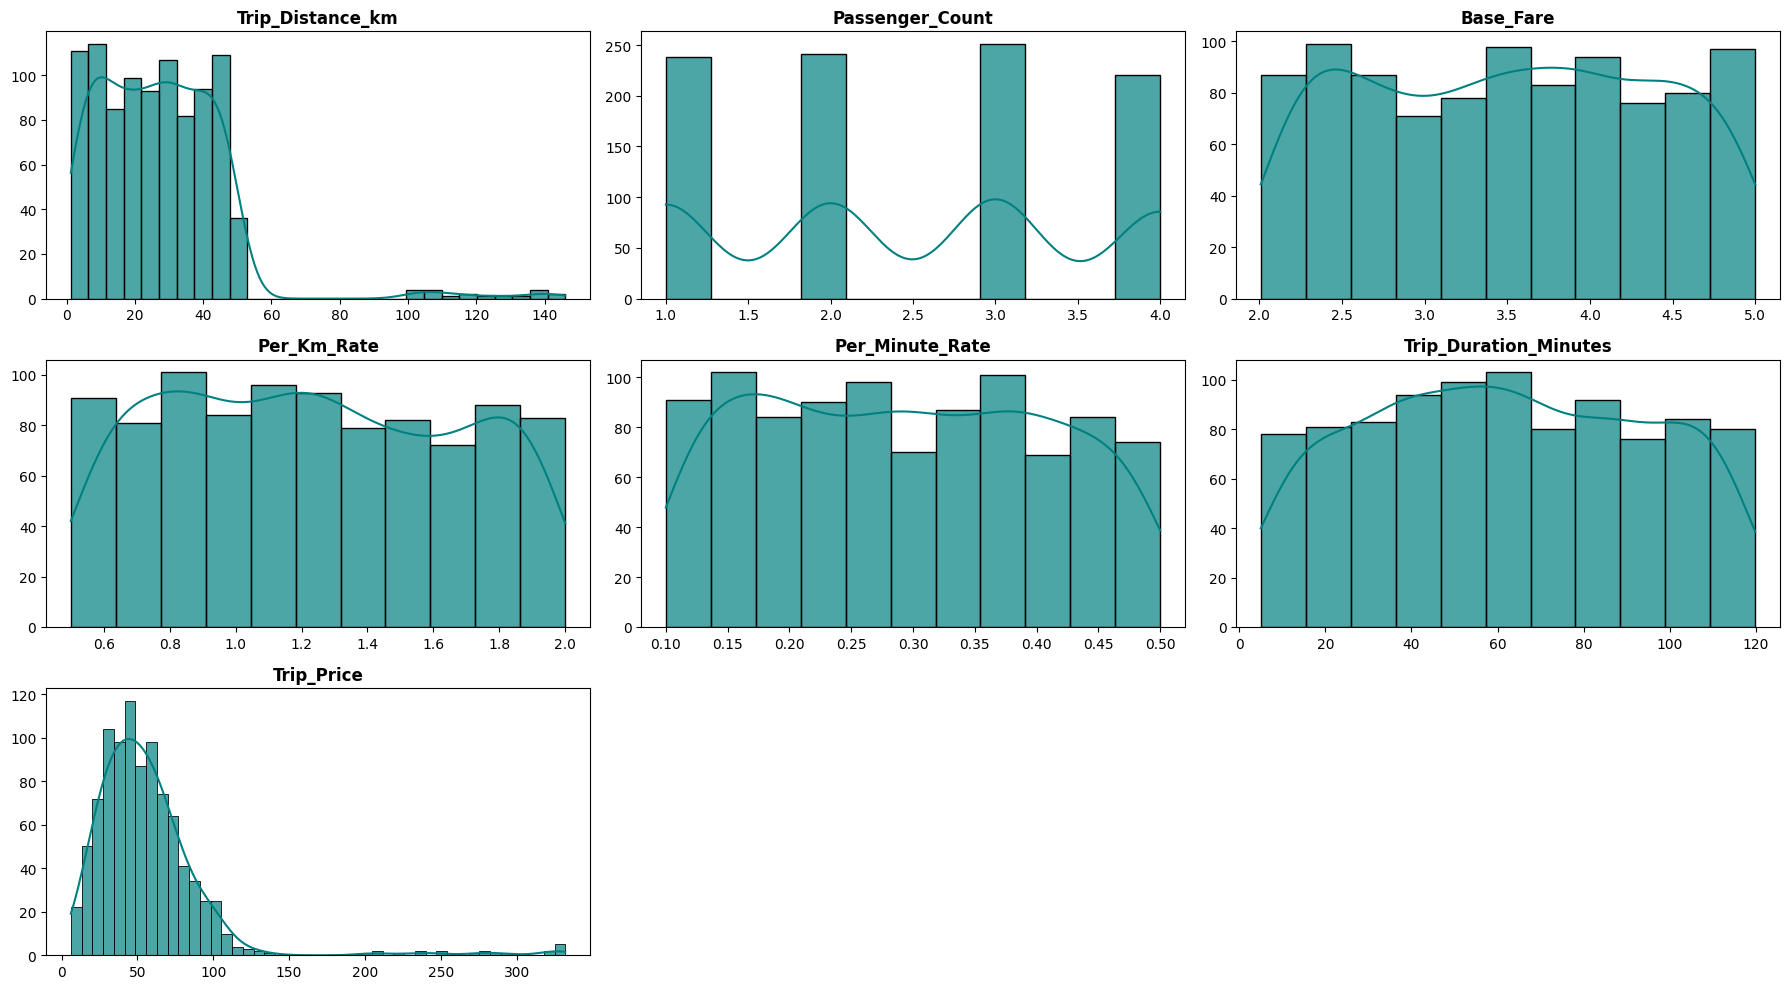

In [13]:
# Visual Distribution

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'Trip_Distance_km',
    'Passenger_Count',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes',
    'Trip_Price'
]

plt.figure(figsize=(18,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)

    # Histogram
    sns.histplot(
        df[col],
        kde=True,
        color='teal',
        edgecolor='black',
        alpha=0.7
    )
    
    plt.title(col, fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('')
    

plt.tight_layout()
plt.show()

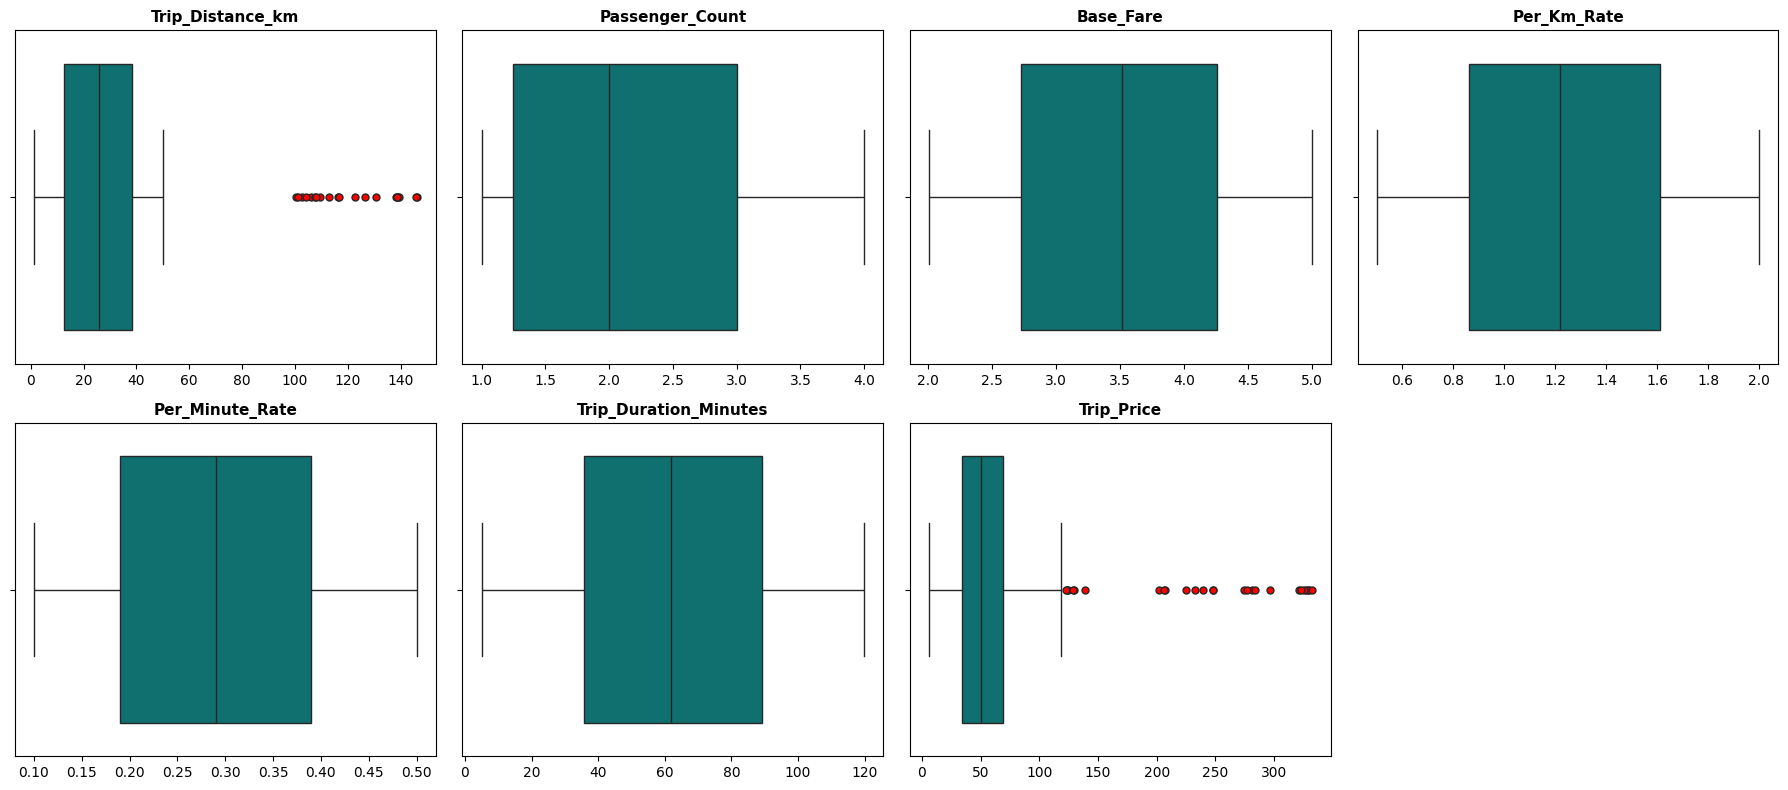

In [14]:
# Boxplot untuk outlier detection

plt.figure(figsize=(18,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)

    sns.boxplot(
    x=df[col],
    color='teal',
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markersize=5,
        linestyle='none'
    )
)
    plt.title(col, fontsize=11, fontweight='bold')
    plt.xlabel("")

plt.tight_layout()
plt.show()

In [15]:
# Tabel Kesimpulan

import pandas as pd
import numpy as np

# Kolom
num_cols = [
    'Trip_Distance_km',
    'Passenger_Count',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes',
    'Trip_Price'
]

cat_cols = [
    'Time_of_Day',
    'Day_of_Week',
    'Traffic_Conditions',
    'Weather'
]

summary_data = []

for col in df.columns:
    
    # Missing Treatment
    if col in cat_cols:
        missing_treatment = '"Unknown"'
    else:
        skew = df[col].skew()
        if abs(skew) > 1:
            missing_treatment = "Median"
        else:
            missing_treatment = "Mean"
    
    # Outlier Detection (numerical only)
    if col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        outlier_detected = "Ya" if outlier_count > 0 else "Tidak"
        
        # Outlier Treatment Logic
        if outlier_count > 0 and abs(df[col].skew()) > 1:
            outlier_treatment = "Retain"
        elif outlier_count > 0:
            outlier_treatment = "Winsorization"
        else:
            outlier_treatment = "Tidak perlu"
            
    else:
        outlier_detected = "N/A"
        outlier_count = "-"
        outlier_treatment = "N/A"
    
    summary_data.append({
        "Variabel": col,
        "Missing Treatment": missing_treatment,
        "Outlier Detected": outlier_detected,
        "Outlier Count": outlier_count,
        "Outlier Treatment": outlier_treatment
    })

summary_table = pd.DataFrame(summary_data)
summary_table.set_index("Variabel")

,Missing Treatment,Outlier Detected,Outlier Count,Outlier Treatment
Variabel,,,,
Trip_Distance_km,Median,Ya,20,Retain
Time_of_Day,"""Unknown""",N/A,-,N/A
Day_of_Week,"""Unknown""",N/A,-,N/A
Passenger_Count,Mean,Tidak,0,Tidak perlu
Traffic_Conditions,"""Unknown""",N/A,-,N/A
Weather,"""Unknown""",N/A,-,N/A
Base_Fare,Mean,Tidak,0,Tidak perlu
Per_Km_Rate,Mean,Tidak,0,Tidak perlu
Per_Minute_Rate,Mean,Tidak,0,Tidak perlu


In [16]:
# backup data asli

df_raw = df.copy()

In [17]:
# inisialisasi data untuk proses cleaning

df_cleans = df.copy()
df_cleans.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


# HANDLING ISSUE

In [18]:
# Handling Missing Value

# Handling Categorical → Unknown
cat_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
for col in cat_cols:
    df_cleans[col] = df_cleans[col].fillna('Unknown')
    
# Highly skewed → median
skewed_cols = ['Trip_Distance_km', 'Trip_Price']
for col in skewed_cols:
    df_cleans[col] = df_cleans[col].fillna(df_cleans[col].median())

# Relatively normal → mean
normal_cols = [
    'Passenger_Count',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes'
]
for col in normal_cols:
    df_cleans[col] = df_cleans[col].fillna(df_cleans[col].mean())

In [19]:
df_cleans.isnull().sum()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

# STANDARISASI TIPE DATA

In [20]:
cat_cols = df_cleans.select_dtypes(include='object').columns

for col in cat_cols:
    df_cleans[col] = df_cleans[col].astype('category')

# LOAD DATASET BEFORE VS AFTER

In [21]:
df_raw.head(10)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.55,1.71,0.48,89.33,60.2028
6,3.85,Afternoon,Weekday,4.0,High,Rain,3.51,1.66,NaN,5.05,11.2645
7,43.44,Evening,Weekend,3.0,NaN,Clear,2.97,1.87,0.23,NaN,101.1216
8,30.45,Morning,Weekday,3.0,High,Clear,2.77,1.78,0.34,110.33,NaN
9,35.70,Afternoon,Weekday,2.0,Low,Rain,3.39,1.52,0.47,NaN,75.5657


In [22]:
df_raw.dtypes

Trip_Distance_km         float64
Time_of_Day               object
Day_of_Week               object
Passenger_Count          float64
Traffic_Conditions        object
Weather                   object
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object

In [23]:
df_raw.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [24]:
df_cleans.head(10)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.560000,0.80,0.320000,53.820000,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,3.502989,0.62,0.430000,40.570000,50.0745
2,36.87,Evening,Weekend,1.0,High,Clear,2.700000,1.21,0.150000,37.270000,52.9032
3,30.33,Evening,Weekday,4.0,Low,Unknown,3.480000,0.51,0.150000,116.810000,36.4698
4,25.83,Evening,Weekday,3.0,High,Clear,2.930000,0.63,0.320000,22.640000,15.6180
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.550000,1.71,0.480000,89.330000,60.2028
6,3.85,Afternoon,Weekday,4.0,High,Rain,3.510000,1.66,0.292916,5.050000,11.2645
7,43.44,Evening,Weekend,3.0,Unknown,Clear,2.970000,1.87,0.230000,62.118116,101.1216
8,30.45,Morning,Weekday,3.0,High,Clear,2.770000,1.78,0.340000,110.330000,50.0745
9,35.70,Afternoon,Weekday,2.0,Low,Rain,3.390000,1.52,0.470000,62.118116,75.5657


In [25]:
df_cleans.dtypes

Trip_Distance_km          float64
Time_of_Day              category
Day_of_Week              category
Passenger_Count           float64
Traffic_Conditions       category
Weather                  category
Base_Fare                 float64
Per_Km_Rate               float64
Per_Minute_Rate           float64
Trip_Duration_Minutes     float64
Trip_Price                float64
dtype: object

In [26]:
df_cleans.isnull().sum()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

In [27]:
df_cleans.to_csv('df_cleans.csv', index = False)

In [28]:
# checking validasi 

df_cek = pd.read_csv('df_cleans.csv')
df_cek.head(10)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.560000,0.80,0.320000,53.820000,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,3.502989,0.62,0.430000,40.570000,50.0745
2,36.87,Evening,Weekend,1.0,High,Clear,2.700000,1.21,0.150000,37.270000,52.9032
3,30.33,Evening,Weekday,4.0,Low,Unknown,3.480000,0.51,0.150000,116.810000,36.4698
4,25.83,Evening,Weekday,3.0,High,Clear,2.930000,0.63,0.320000,22.640000,15.6180
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.550000,1.71,0.480000,89.330000,60.2028
6,3.85,Afternoon,Weekday,4.0,High,Rain,3.510000,1.66,0.292916,5.050000,11.2645
7,43.44,Evening,Weekend,3.0,Unknown,Clear,2.970000,1.87,0.230000,62.118116,101.1216
8,30.45,Morning,Weekday,3.0,High,Clear,2.770000,1.78,0.340000,110.330000,50.0745
9,35.70,Afternoon,Weekday,2.0,Low,Rain,3.390000,1.52,0.470000,62.118116,75.5657


In [29]:
# cek nilai unik setelah cleaning
summary_unique = pd.DataFrame({
    'Unique_Count': df_cleans.nunique(),
    'Sample_Values': df_cleans.apply(lambda x: list(x.unique())[:5])
})

summary_unique

,Unique_Count,Sample_Values
Trip_Distance_km,868,"[19.35, 47.59, 36.87, 30.33, 25.83]"
Time_of_Day,5,"[Morning, Afternoon, Evening, Night, Unknown]"
Day_of_Week,3,"[Weekday, Weekend, Unknown]"
Passenger_Count,5,"[3.0, 1.0, 4.0, 2.0, 2.4768421052631577]"
Traffic_Conditions,4,"[Low, High, Medium, Unknown]"
Weather,4,"[Clear, Unknown, Rain, Snow]"
Base_Fare,291,"[3.56, 3.502989473684211, 2.7, 3.48, 2.93]"
Per_Km_Rate,151,"[0.8, 0.62, 1.21, 0.51, 0.63]"
Per_Minute_Rate,42,"[0.32, 0.43, 0.15, 0.48, 0.2929157894736842]"
Trip_Duration_Minutes,918,"[53.82, 40.57, 37.27, 116.81, 22.64]"


# EDA

## CORRELATION ANALYSIS OF AFFECTING TRIP PRICE

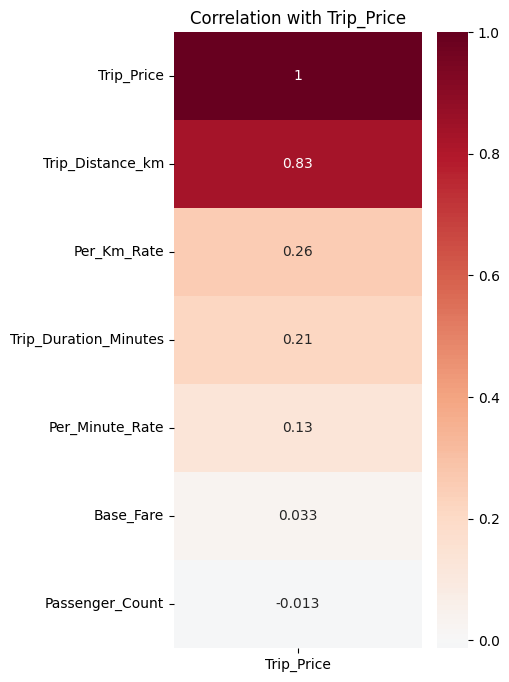

In [30]:
target = df_cleans['Trip_Price']

corr_with_target = df_cleans.corr(numeric_only=True)['Trip_Price']

corr_with_target = corr_with_target.sort_values(ascending=False)

plt.figure(figsize=(4,8))
sns.heatmap(corr_with_target.to_frame(), cmap='RdBu_r', annot=True, center=0)
plt.title("Correlation with Trip_Price")
plt.show()

- Harga perjalanan paling banyak dipengaruhi oleh jarak tempuh.
- Semakin jauh jaraknya, semakin mahal harganya — dan pengaruhnya sangat kuat.
- Durasi perjalanan dan tarif per kilometer juga berpengaruh, tetapi tidak sebesar jarak.
- Sementara itu, tarif dasar (base fare) dan jumlah penumpang hampir tidak memengaruhi variasi harga.

**`Kesimpulannya, sistem penentuan harga pada data ini lebih berfokus pada jarak dibandingkan faktor lainnya`**.

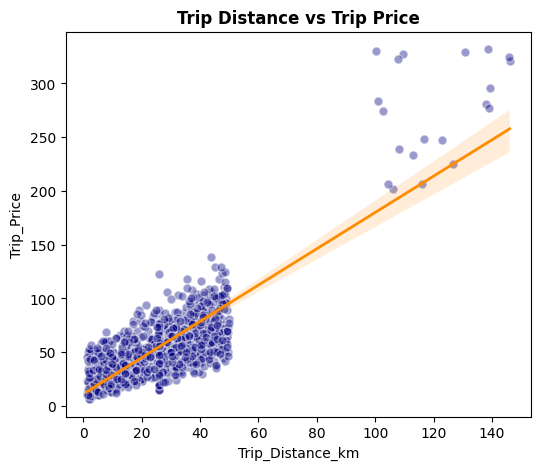

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.regplot(
    x='Trip_Distance_km',
    y='Trip_Price',
    data=df_cleans,
    scatter_kws={
        'alpha':0.4,
        'color':'navy',      # warna titik
        'edgecolor':'white',
        's':40
    },
    line_kws={
        'color':'darkorange',     # warna garis regresi
        'linewidth':2
    }
)

plt.title("Trip Distance vs Trip Price", fontsize=12, fontweight='bold')
plt.xlabel("Trip_Distance_km")
plt.ylabel("Trip_Price")
plt.show()

- Grafik menunjukkan hubungan positif yang kuat antara jarak dan harga perjalanan, dengan nilai korelasi sebesar **0.83**.

  Artinya:

    - Semakin jauh jarak tempuh, semakin tinggi harga trip.

    - Setiap kenaikan jarak secara konsisten diikuti kenaikan harga

    - Beberapa titik jarak sangat jauh (di atas 100 km) memang memiliki harga tinggi, tetapi tetap mengikuti pola garis tren utama.
 
Kesimpulan :

**`Harga trip terutama ditentukan oleh jarak. Semakin jauh perjalanan, semakin mahal harganya`**.

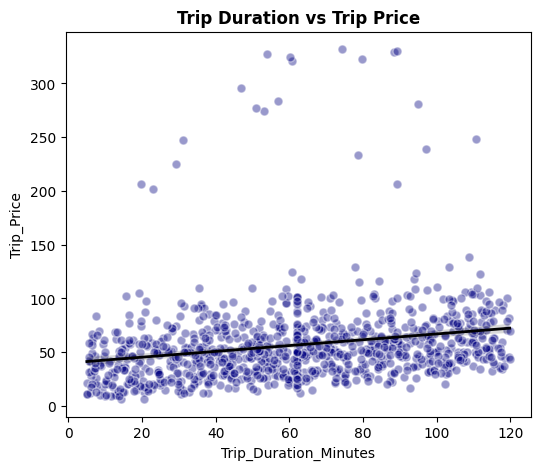

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.regplot(
    x='Trip_Duration_Minutes',
    y='Trip_Price',
    data=df_cleans,
    scatter_kws={
        'alpha':0.4,
        'color':'navy',    
        'edgecolor':'white',
        's':40
    },
    line_kws={
        'color':'black',
        'linewidth':2
    }
)

plt.title("Trip Duration vs Trip Price", fontsize=12, fontweight='bold')
plt.xlabel("Trip_Duration_Minutes")
plt.ylabel("Trip_Price")
plt.show()

- Grafik menunjukkan hubungan positif tetapi lemah antara durasi perjalanan dan harga trip, dengan nilai korelasi sekitar 0.21.

  Artinya:

    - Semakin lama durasi perjalanan, harga memang cenderung naik.

    - Namun kenaikannya tidak terlalu kuat dibandingkan faktor jarak.

    - Banyak perjalanan dengan durasi yang mirip tetapi memiliki harga yang berbeda-beda.

Kesimpulan:

**`Lama perjalanan memang berpengaruh terhadap harga, tetapi bukan faktor utama. Harga lebih banyak ditentukan oleh jarak tempuh dibandingkan durasi waktu`**.

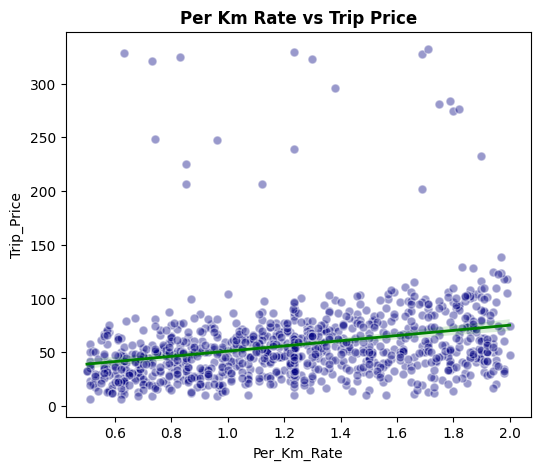

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.regplot(
    x='Per_Km_Rate',
    y='Trip_Price',
    data=df_cleans,
    scatter_kws={
        'alpha':0.4,
        'color':'navy',    
        'edgecolor':'white',
        's':40
    },
    line_kws={
        'color':'green',
        'linewidth':2
    }
)

plt.title("Per Km Rate vs Trip Price", fontsize=12, fontweight='bold')
plt.xlabel("Per_Km_Rate")
plt.ylabel("Trip_Price")
plt.show()

- Grafik menunjukkan hubungan positif tetapi tidak terlalu kuat antara tarif per kilometer (Per_Km_Rate) dan harga trip, dengan korelasi sekitar 0.26.

  Artinya:

    - Semakin tinggi tarif per km, harga perjalanan memang cenderung naik.

    - Namun pengaruhnya tidak sebesar jarak tempuh.

    - Banyak perjalanan dengan tarif per km yang mirip tetapi harga akhirnya tetap berbeda.

Kesimpulan:

**`Tarif per km memang berpengaruh terhadap harga, tetapi bukan faktor utama. Harga paling kuat dipengaruhi oleh jarak tempuh perjalanan, bukan hanya tarif per km saja`**.

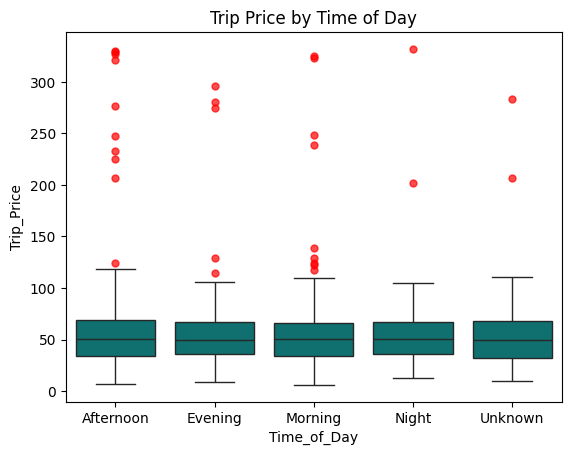

In [34]:
sns.boxplot(
    x='Time_of_Day',
    y='Trip_Price',
    data=df_cleans,
    color='teal',
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markeredgecolor='red',
        markersize=5,
        alpha=0.7
    )
)

plt.title("Trip Price by Time of Day")
plt.show()

- Grafik menunjukkan bahwa harga perjalanan pada Afternoon, Evening, Morning, dan Night relatif mirip.

  Artinya:

    - Tidak ada perbedaan harga yang signifikan berdasarkan waktu.

    - Harga rata-rata di semua waktu berada di kisaran yang hampir sama (sekitar ±40–60).

    - Beberapa harga sangat tinggi (di atas 200–300) muncul di semua waktu, jadi itu bukan karena jam tertentu.

Kesimpulan:

**`Waktu perjalanan bukan faktor utama yang menentukan harga. Harga lebih dipengaruhi oleh faktor lain, seperti jarak tempuh`**.

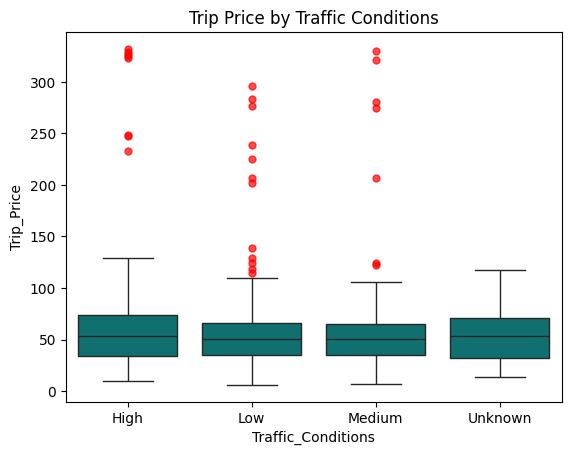

In [35]:
sns.boxplot(
    x='Traffic_Conditions',
    y='Trip_Price',
    data=df_cleans,
    color='teal',
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markeredgecolor='red',
        markersize=5,
        alpha=0.7
    )
)

plt.title("Trip Price by Traffic Conditions")
plt.show()

- Grafik menunjukkan bahwa harga perjalanan pada kondisi High, Medium, dan Low traffic relatif mirip.

  Artinya:

    - Tidak ada perbedaan harga yang signifikan meskipun kondisi lalu lintas berbeda.

    - Harga rata-rata tetap berada di kisaran sekitar 40–60 di semua kondisi.

    - Beberapa harga sangat tinggi (di atas 200–300) muncul di semua kategori, jadi bukan hanya karena macet.

Kesimpulan:

**`Kondisi lalu lintas tidak terlalu memengaruhi harga secara langsung. Harga perjalanan lebih dipengaruhi oleh faktor lain, terutama jarak tempuh`**.

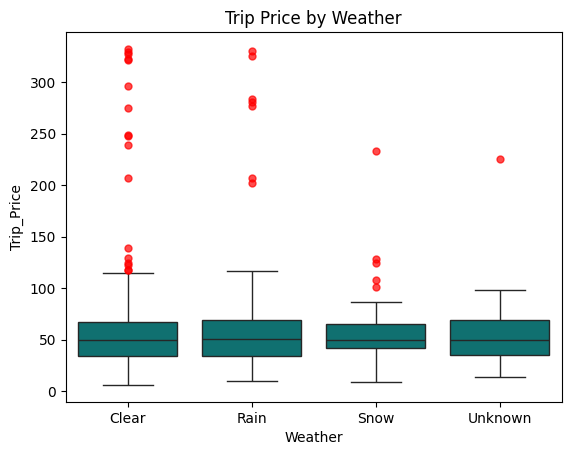

In [36]:
sns.boxplot(
    x='Weather',
    y='Trip_Price',
    data=df_cleans,
    color='teal',
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markeredgecolor='red',
        markersize=5,
        alpha=0.7
    )
)

plt.title("Trip Price by Weather")
plt.show()

- Grafik menunjukkan bahwa harga perjalanan pada kondisi Clear, Rain, Snow, dan Unknown relatif mirip.

  Artinya:

    - Harga rata-rata tetap berada di kisaran sekitar 40–60 di semua kondisi cuaca.

    - Saat hujan atau salju, harga tidak meningkat secara signifikan dibanding cuaca cerah.

    - Beberapa harga sangat tinggi (di atas 200–300) muncul di berbagai kondisi cuaca, jadi bukan karena cuaca tertentu.

Kesimpulan:

**`Cuaca tidak terlalu memengaruhi harga perjalanan secara langsung. Harga lebih banyak dipengaruhi oleh faktor jarak tempuh dibanding kondisi cuaca`**.

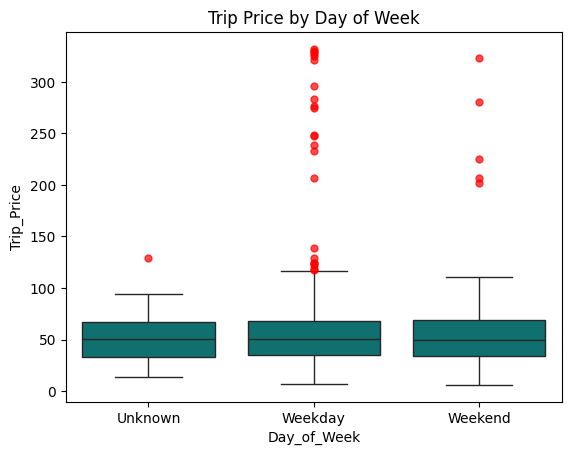

In [37]:
sns.boxplot(
    x='Day_of_Week',
    y='Trip_Price',
    data=df_cleans,
    color='teal',
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markeredgecolor='red',
        markersize=5,
        alpha=0.7
    )
)

plt.title("Trip Price by Day of Week")
plt.show()

- Grafik menunjukkan bahwa harga perjalanan pada weekday dan weekend hampir sama.

  Artinya:

    - Harga rata-rata di kedua hari berada di kisaran sekitar 40–60.

    - Tidak ada lonjakan harga signifikan saat weekend.

    - Beberapa harga sangat tinggi (di atas 200–300) muncul di weekday maupun weekend, jadi bukan karena jenis hari tertentu.

Kesimpulan:

**`Hari dalam minggu tidak terlalu memengaruhi harga perjalanan. Harga tetap lebih banyak ditentukan oleh jarak tempuh dibanding apakah itu weekday atau weekend`**.

Berdasarkan analisis data:

1. Harga perjalanan paling dipengaruhi oleh **jarak tempuh**. Semakin jauh jaraknya, semakin mahal harganya. **Hubungannya kuat (korelasi ±0.83)**.
2. Durasi perjalanan berpengaruh, tetapi tidak terlalu kuat. Lama perjalanan memang membuat harga naik, tetapi tidak sebesar pengaruh jarak.
3. Tarif per kilometer juga ikut memengaruhi harga, namun dampaknya sedang.
4. Faktor waktu (pagi, siang, malam), cuaca, hari, dan kondisi lalu lintas tidak menunjukkan perbedaan harga yang signifikan. Artinya, sistem harga lebih berbasis jarak dibanding faktor eksternal.

KESIMPULAN:
**`Harga taxi terutama ditentukan oleh seberapa jauh jarak tempuh perjalanan, bukan kapan atau dalam kondisi apa perjalanan dilakukan.`**